# Data Analyst Job Market Analysis

### Importing necessary libraries

In [323]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load the CSV files

In [324]:
# load the csv files
data= pd.read_csv('DataAnalyst.csv')
data.head()

,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply
0,0,"Data Analyst, Center on Immigration and Justic...",$37K-$66K (Glassdoor est.),Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice\n3.2,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,Social Assistance,Non-Profit,$100 to $500 million (USD),-1,True
1,1,Quality Data Analyst,$37K-$66K (Glassdoor est.),Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York\n3.8,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1,-1
2,2,"Senior Data Analyst, Insights & Analytics Team...",$37K-$66K (Glassdoor est.),We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace\n3.4,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,GoDaddy,-1
3,3,Data Analyst,$37K-$66K (Glassdoor est.),Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity\n4.1,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,IT Services,Information Technology,$50 to $100 million (USD),-1,-1
4,4,Reporting Data Analyst,$37K-$66K (Glassdoor est.),ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel\n3.9,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,True


### Data cleaning and preprocessing

In [325]:
# data cleaning and preprocessing 
data.info()
data.dropna(inplace=True)
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2253 entries, 0 to 2252
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         2253 non-null   int64  
 1   Job Title          2253 non-null   object 
 2   Salary Estimate    2253 non-null   object 
 3   Job Description    2253 non-null   object 
 4   Rating             2253 non-null   float64
 5   Company Name       2252 non-null   object 
 6   Location           2253 non-null   object 
 7   Headquarters       2253 non-null   object 
 8   Size               2253 non-null   object 
 9   Founded            2253 non-null   int64  
 10  Type of ownership  2253 non-null   object 
 11  Industry           2253 non-null   object 
 12  Sector             2253 non-null   object 
 13  Revenue            2253 non-null   object 
 14  Competitors        2253 non-null   object 
 15  Easy Apply         2253 non-null   object 
dtypes: float64(1), int64(2),

Unnamed: 0           0
Job Title            0
Salary Estimate      0
Job Description      0
Rating               0
Company Name         0
Location             0
Headquarters         0
Size                 0
Founded              0
Type of ownership    0
Industry             0
Sector               0
Revenue              0
Competitors          0
Easy Apply           0
dtype: int64

In [326]:
# cleaning job titles by categorizing them into broader roles
def clean_job_role(title):
    title = title.lower()

    if any(x in title for x in ['lead', 'manager', 'head']):
        return 'Lead Data Analyst'
    elif any(x in title for x in ['senior', 'sr', 'principal']):
        return 'Senior Data Analyst'
    elif any(x in title for x in ['junior', 'jr', 'entry', 'associate', 'trainee']):
        return 'Junior Data Analyst'
    elif any(x in title for x in ['business', 'product', 'operations']):
        return 'Business Data Analyst'
    elif any(x in title for x in ['quality', 'governance', 'compliance']):
        return 'Data Quality / Governance Analyst'
    else:
        return 'Data Analyst'

data['Clean Job Role'] = data['Job Title'].apply(clean_job_role)

# drop the original 'Job Title' column
data.drop('Job Title', axis=1, inplace=True)

# put Clean Job Role column before Salary Estimate column
cols = data.columns.tolist()
cols.insert(cols.index('Salary Estimate'), cols.pop(cols.index('Clean Job Role')))
data = data[cols]


In [327]:
# change datatype of founded column to datetime(year)
data['Founded'] = pd.to_datetime(data['Founded'], errors='coerce').dt.year



In [328]:
# remove unnecessary columns and clean the columns if any has incorrect data
data.drop(columns=['Unnamed: 0'], inplace=True)

# clean salary column and convert it to numeric
data['Salary Estimate'] = data['Salary Estimate'].astype(str)

data['Salary Estimate'] = data['Salary Estimate'].str.replace('$', '',regex=False).str.replace('K', '',regex=False).str.replace('(Glassdoor est.)', '',regex=False)


In [329]:

data['Salary Estimate'].head()

0    37-66 
1    37-66 
2    37-66 
3    37-66 
4    37-66 
Name: Salary Estimate, dtype: object

In [330]:
# FILLING ESTIMATE SALRY WITH THE AVG SALARY
# change salary estimate datatype from string to integer

data[['Min_Salary','Max_Salary']] = data['Salary Estimate'].str.split('-', expand=True).astype(str)

data['Min_Salary'] = pd.to_numeric(data['Min_Salary'], errors='coerce')
data['Max_Salary'] = pd.to_numeric(data['Max_Salary'], errors='coerce')

data['Avg_Salary'] = (data['Min_Salary'] + data['Max_Salary']) / 2

# rename column 'Salary Estimate' to 'Salary_estimate in K'
data.rename(columns={'Salary Estimate': 'Salary_estimate in K', 'Avg_Salary': 'Avg_salary in K '}, inplace=True)


In [331]:
data[['Salary_estimate in K', 'Min_Salary', 'Max_Salary', 'Avg_salary in K ']].head()
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2252 entries, 0 to 2252
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Clean Job Role        2252 non-null   object 
 1   Salary_estimate in K  2252 non-null   object 
 2   Job Description       2252 non-null   object 
 3   Rating                2252 non-null   float64
 4   Company Name          2252 non-null   object 
 5   Location              2252 non-null   object 
 6   Headquarters          2252 non-null   object 
 7   Size                  2252 non-null   object 
 8   Founded               2252 non-null   int32  
 9   Type of ownership     2252 non-null   object 
 10  Industry              2252 non-null   object 
 11  Sector                2252 non-null   object 
 12  Revenue               2252 non-null   object 
 13  Competitors           2252 non-null   object 
 14  Easy Apply            2252 non-null   object 
 15  Min_Salary            2251

In [332]:
data.head()

,Clean Job Role,Salary_estimate in K,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply,Min_Salary,Max_Salary,Avg_salary in K
0,Data Analyst,37-66,Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice\n3.2,"New York, NY","New York, NY",201 to 500 employees,1970,Nonprofit Organization,Social Assistance,Non-Profit,$100 to $500 million (USD),-1,True,37.0,66,51.5
1,Data Quality / Governance Analyst,37-66,Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York\n3.8,"New York, NY","New York, NY",10000+ employees,1970,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1,-1,37.0,66,51.5
2,Senior Data Analyst,37-66,We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace\n3.4,"New York, NY","New York, NY",1001 to 5000 employees,1970,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,GoDaddy,-1,37.0,66,51.5
3,Data Analyst,37-66,Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity\n4.1,"New York, NY","McLean, VA",201 to 500 employees,1970,Subsidiary or Business Segment,IT Services,Information Technology,$50 to $100 million (USD),-1,-1,37.0,66,51.5
4,Data Analyst,37-66,ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel\n3.9,"New York, NY","New York, NY",501 to 1000 employees,1970,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,True,37.0,66,51.5


In [333]:
# correct columns Competitors, Company Name and Easy Apply
data['Company Name'] = data['Company Name'].str.split('\n').str[0]



In [334]:
data['Competitors'].value_counts()
data['Easy Apply'].value_counts()


Easy Apply
-1      2172
True      80
Name: count, dtype: int64

In [335]:
data['Competitors'].apply(type).value_counts()

Competitors
<class 'str'>    2252
Name: count, dtype: int64

In [336]:
# Competitors

data['Competitors'] = data['Competitors'].replace('-1', 'Not Available')

data['Competitors'].value_counts()

Competitors
Not Available                                                1731
Adecco, Manpower                                               14
Robert Half, Insight Global                                    14
Google, Microsoft, Samsung Electronics                         10
Artech Information Systems, Mindlance, Tech Mahindra           10
                                                             ... 
Cognizant Technology Solutions, Infosys, HCL Technologies       1
Equinix, Digital Realty, CyrusOne                               1
WeDo technologies, Intec Telecom, Amdocs                        1
Thomson Reuters, Hearst, Pearson                                1
Travelers, Chubb, Crum & Forster                                1
Name: count, Length: 291, dtype: int64

In [337]:
# Easy apply
data['Easy Apply'] = data['Easy Apply'].replace(-1, 'False')
data['Easy Apply'] = data['Easy Apply'].astype(bool)
data['Easy Apply'].value_counts()


Easy Apply
True    2252
Name: count, dtype: int64

In [338]:
# Industry 
data['Industry'] = data['Industry'].replace('-1', 'Not Available')

In [339]:
#Sector
data['Sector'] = data['Sector'].replace('-1', 'Not Available')

In [340]:
# Company size
data['Size'] = data['Size'].replace('-1', 'Not specified')

In [341]:
data.head()

,Clean Job Role,Salary_estimate in K,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply,Min_Salary,Max_Salary,Avg_salary in K
0,Data Analyst,37-66,Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice,"New York, NY","New York, NY",201 to 500 employees,1970,Nonprofit Organization,Social Assistance,Non-Profit,$100 to $500 million (USD),Not Available,True,37.0,66,51.5
1,Data Quality / Governance Analyst,37-66,Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York,"New York, NY","New York, NY",10000+ employees,1970,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),Not Available,True,37.0,66,51.5
2,Senior Data Analyst,37-66,We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace,"New York, NY","New York, NY",1001 to 5000 employees,1970,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,GoDaddy,True,37.0,66,51.5
3,Data Analyst,37-66,Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity,"New York, NY","McLean, VA",201 to 500 employees,1970,Subsidiary or Business Segment,IT Services,Information Technology,$50 to $100 million (USD),Not Available,True,37.0,66,51.5
4,Data Analyst,37-66,ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel,"New York, NY","New York, NY",501 to 1000 employees,1970,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,True,37.0,66,51.5


### Feature Engineering

In [342]:
# creating Experience level column based on job titles
def get_experience_level(title):
    title = title.lower()

    if any(x in title for x in ['intern', 'junior', 'jr', 'entry', 'associate', 'trainee']):
        return 'Entry-Level'
    elif any(x in title for x in ['senior', 'sr', 'principal']):
        return 'Senior-Level'
    elif any(x in title for x in ['lead', 'manager', 'head']):
        return 'Lead-Level'
    else:
        return 'Mid-Level'

data['Experience Level'] = data['Clean Job Role'].apply(get_experience_level)


### Exploratory Data Analysis (EDA)

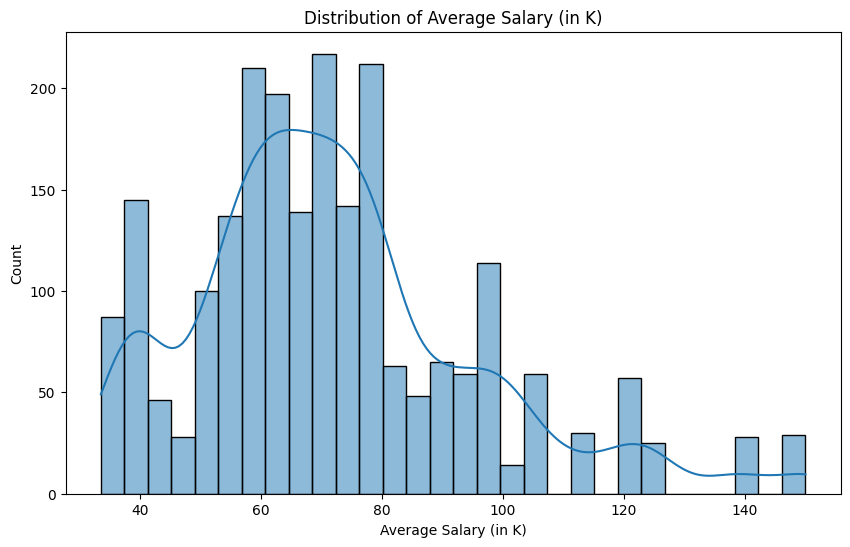

In [343]:
# Salary Distribution
plt.figure(figsize=(10, 6))
sns.histplot(data['Avg_salary in K '], bins=30, kde=True)
plt.title('Distribution of Average Salary (in K)')
plt.xlabel('Average Salary (in K)')

plt.show()

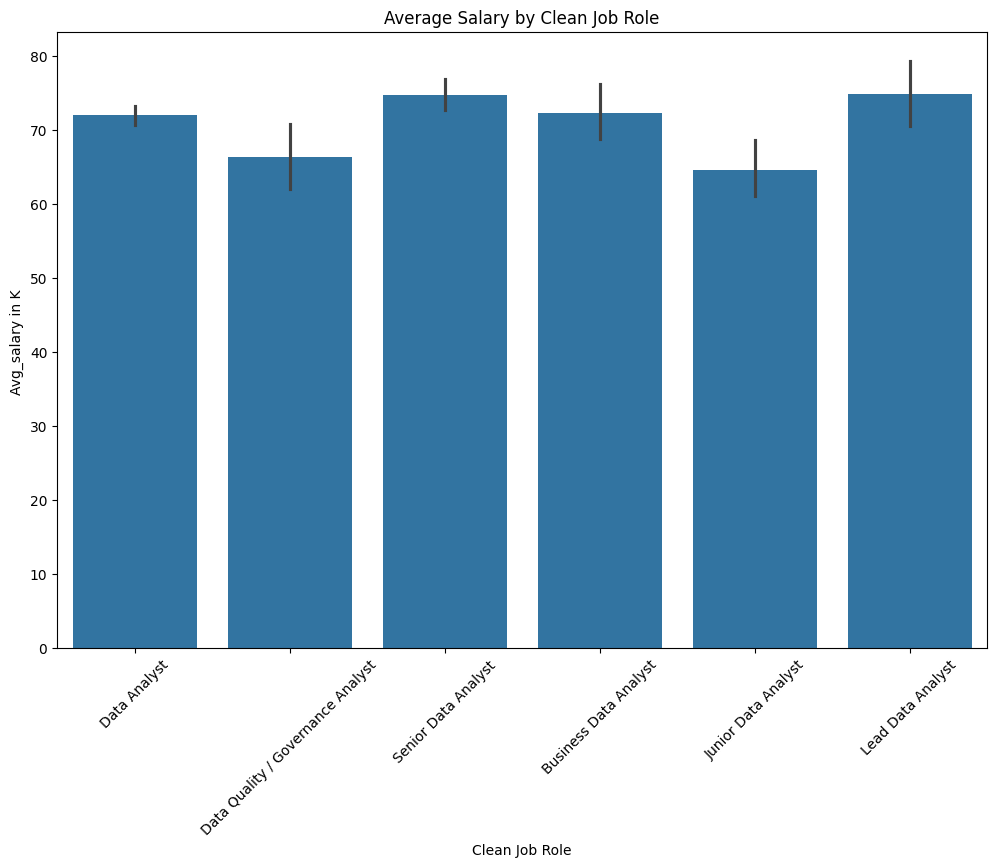

In [344]:
# Average Salary by Job Title

top_titles= data['Clean Job Role'].value_counts().head(10).index
data_top_titles = data[data['Clean Job Role'].isin(top_titles)]

plt.figure(figsize=(12,8))
sns.barplot(x='Clean Job Role', y='Avg_salary in K ', data=data_top_titles) 
plt.title('Average Salary by Clean Job Role')
plt.xticks(rotation=45)
plt.show()

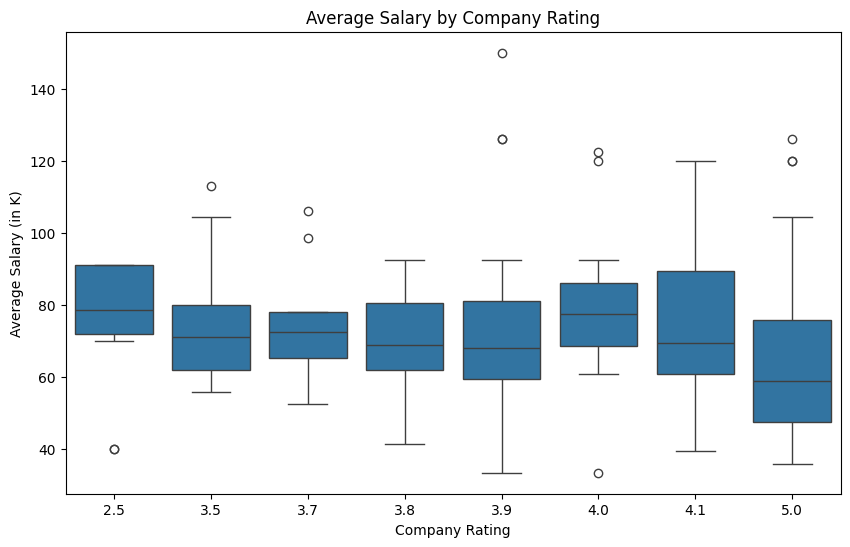

In [345]:
#  top 10 company by rating in salary
top_companies= data['Company Name'].value_counts().head(10).index

data_top_companies = data[data['Company Name'].isin(top_companies)]

plt.figure(figsize=(10, 6))
sns.boxplot(x='Rating', y='Avg_salary in K ', data=data_top_companies)
plt.title('Average Salary by Company Rating')
plt.xlabel('Company Rating')
plt.ylabel('Average Salary (in K)')
plt.show()

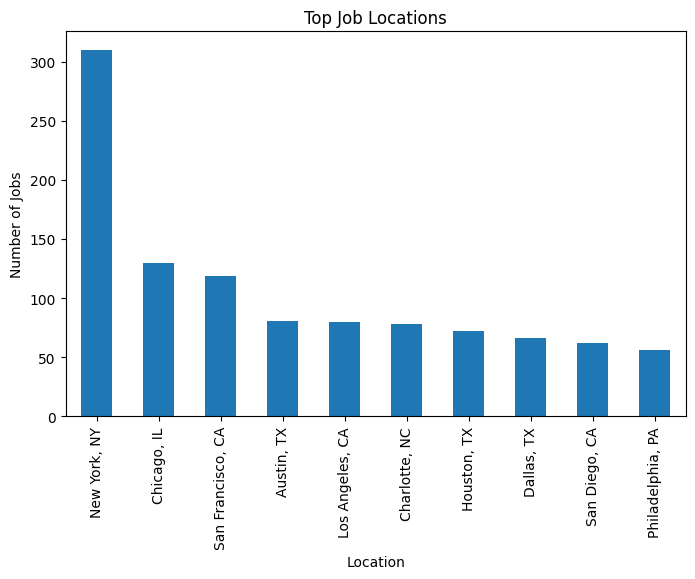

In [346]:
# Location Analysis
data['Location'].value_counts().head(10)
top_locations = data['Location'].value_counts().head(10)
top_locations.plot(kind='bar', figsize=(8,5), title='Top Job Locations')
plt.xlabel('Location')
plt.ylabel('Number of Jobs')
plt.show()



In [347]:
# Industry trends
data['Industry'].value_counts().head(10)

Industry
Not Available                              352
IT Services                                325
Staffing & Outsourcing                     323
Health Care Services & Hospitals           151
Computer Hardware & Software               111
Consulting                                 111
Investment Banking & Asset Management       78
Enterprise Software & Network Solutions     69
Internet                                    65
Advertising & Marketing                     51
Name: count, dtype: int64

In [348]:
# Sector Trends
data['Industry'].value_counts().head(10)
data['Sector'].value_counts().head(10)



Sector
Information Technology    570
Business Services         524
Not Available             352
Finance                   169
Health Care               151
Education                  52
Insurance                  51
Accounting & Legal         43
Media                      42
Manufacturing              40
Name: count, dtype: int64

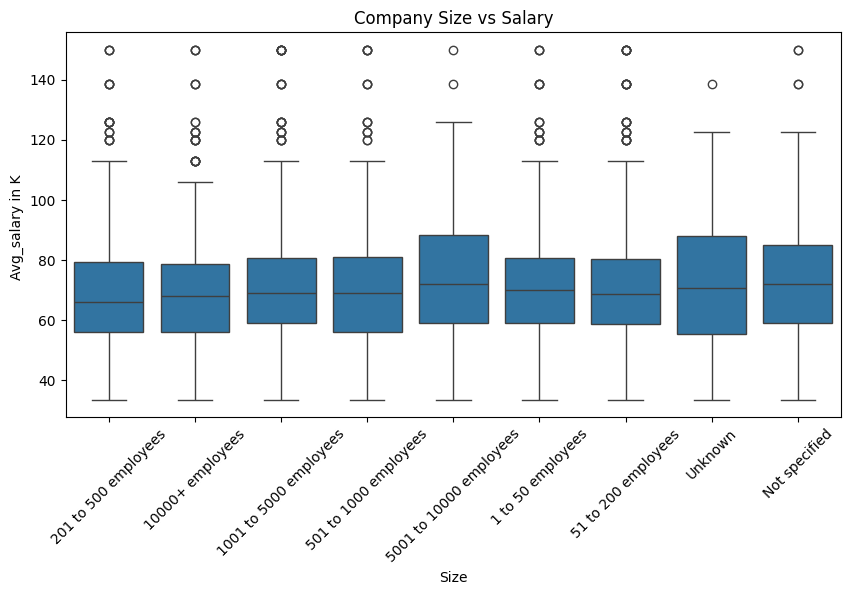

In [349]:
# Company Size vs Salary
plt.figure(figsize=(10,5))
sns.boxplot(x='Size', y='Avg_salary in K ', data=data)
plt.xticks(rotation=45)
plt.title("Company Size vs Salary")
plt.show()


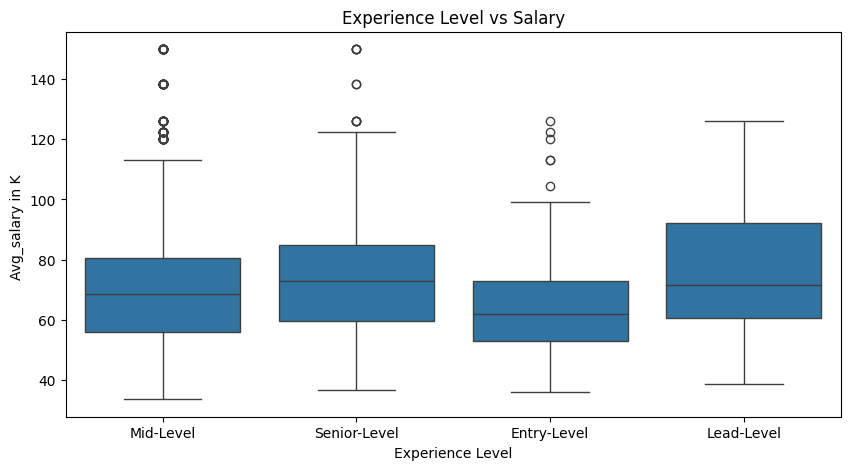

In [354]:
# Experience Level vs Salary
plt.figure(figsize=(10,5))
sns.boxplot(x='Experience Level', y='Avg_salary in K ', data=data)
plt.title("Experience Level vs Salary")
plt.show()


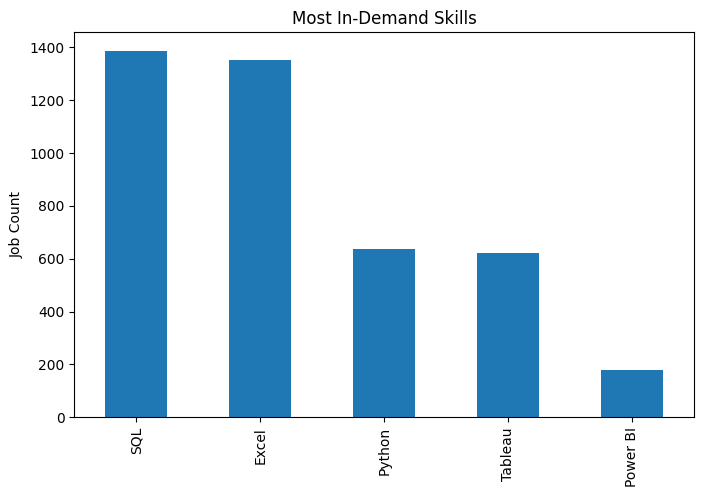

In [350]:
# Skill Demand Analysis ( Key extraction from Job Description)
skills = {
    'Python': 'python',
    'SQL': 'sql',
    'Excel': 'excel',
    'Tableau': 'tableau',
    'Power BI': 'power bi'
}

for skill, keyword in skills.items():
    data[skill] = data['Job Description'].str.lower().str.contains(keyword)

skill_demand = data[list(skills.keys())].sum().sort_values(ascending=False)
skill_demand
skill_demand.plot(kind='bar', figsize=(8,5), title="Most In-Demand Skills")
plt.ylabel("Job Count")
plt.show()

   


In [351]:
data.head()

,Clean Job Role,Salary_estimate in K,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,...,Easy Apply,Min_Salary,Max_Salary,Avg_salary in K,Experience Level,Python,SQL,Excel,Tableau,Power BI
0,Data Analyst,37-66,Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice,"New York, NY","New York, NY",201 to 500 employees,1970,Nonprofit Organization,...,True,37.0,66,51.5,Mid-Level,True,True,False,False,False
1,Data Quality / Governance Analyst,37-66,Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York,"New York, NY","New York, NY",10000+ employees,1970,Nonprofit Organization,...,True,37.0,66,51.5,Mid-Level,False,True,True,False,False
2,Senior Data Analyst,37-66,We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace,"New York, NY","New York, NY",1001 to 5000 employees,1970,Company - Private,...,True,37.0,66,51.5,Senior-Level,True,True,True,True,False
3,Data Analyst,37-66,Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity,"New York, NY","McLean, VA",201 to 500 employees,1970,Subsidiary or Business Segment,...,True,37.0,66,51.5,Mid-Level,False,True,False,True,False
4,Data Analyst,37-66,ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel,"New York, NY","New York, NY",501 to 1000 employees,1970,Company - Private,...,True,37.0,66,51.5,Mid-Level,True,True,True,False,False


In [352]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2252 entries, 0 to 2252
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Clean Job Role        2252 non-null   object 
 1   Salary_estimate in K  2252 non-null   object 
 2   Job Description       2252 non-null   object 
 3   Rating                2252 non-null   float64
 4   Company Name          2252 non-null   object 
 5   Location              2252 non-null   object 
 6   Headquarters          2252 non-null   object 
 7   Size                  2252 non-null   object 
 8   Founded               2252 non-null   int32  
 9   Type of ownership     2252 non-null   object 
 10  Industry              2252 non-null   object 
 11  Sector                2252 non-null   object 
 12  Revenue               2252 non-null   object 
 13  Competitors           2252 non-null   object 
 14  Easy Apply            2252 non-null   bool   
 15  Min_Salary            2251

In [353]:
# DOWNLOAD THE CSV FILE
data.to_excel('cleaned_data_analyst_jobs.xlsx', index=False)
 

### Business Insights

1. Salary Trends

   The majority of Data Analyst roles offer salaries in the mid-range ($50K–$80K), indicating strong demand for mid-level professionals.

   Senior Data Analyst positions consistently command higher salaries, reflecting the premium placed on experience and advanced analytical skills.

   Salary variation across companies suggests compensation is influenced not just by role, but also by industry, company size, and rating.

2. Skill Demand Insights

   SQL and Python appear most frequently in job descriptions, making them the core technical requirements for Data Analyst roles.

   Spreadsheet and BI tools such as Excel, Tableau, and Power BI remain essential for reporting and dashboarding.

   Roles increasingly expect candidates to combine technical skills with business understanding, not just data handling.

3. Industry & Sector Trends

   The Information Technology and Healthcare sectors are the largest employers of Data Analysts.

   Internet-based and technology-driven companies show higher hiring frequency, reflecting data-driven decision-making cultures.

   Non-profit and service-based organizations offer roles but often with lower salary ranges.

4. Company Characteristics

   Mid-to-large-sized companies tend to offer higher and more stable salaries compared to smaller firms.

   Companies with higher Glassdoor ratings generally provide better compensation, suggesting a positive relationship between employee satisfaction and pay.

   Many companies do not list competitors, indicating either niche markets or limited competitive transparency.

5. Hiring Convenience

   The Easy Apply option is not universally available, suggesting that many employers still prefer traditional or customized application processes.

   Roles offering Easy Apply may attract higher application volumes and faster hiring cycles.

### Recommendations

1. For Aspiring Data Analysts

   Focus on mastering SQL and Python, as they are non-negotiable skills in the job market.

   Build hands-on projects involving real-world datasets, dashboards, and business problem solving.

   Target IT, Healthcare, and Internet-based companies for higher job availability and better salary prospects.

2. For Job Seekers Targeting Higher Pay

   Aim for mid-to-large organizations and higher-rated companies.

   Develop advanced skills such as data modeling, forecasting, and dashboard automation to qualify for senior roles.

   Highlight business impact and decision-making outcomes in resumes and interviews.

3. For Employers & Recruiters

   Clearly listing salary ranges and required skills can attract better-qualified candidates.

   Offering Easy Apply options may improve candidate reach and speed up hiring.

   Competitive compensation aligned with market standards can enhance employer branding.

### Conclusion

This analysis highlights a strong and growing demand for Data Analysts, particularly in technology-driven and data-intensive industries.
Employers seek professionals who combine technical proficiency, analytical thinking, and business insight.

For candidates, developing in-demand skills, targeting the right industries, and showcasing real-world projects significantly improves employability.
Overall, the Data Analyst job market remains competitive but rewarding for professionals who align their skills with market needs.